# **01: EXPLORATION & BASELINE CNN MODEL**

### **Purpose: Initial data exploration and baseline CNN model development**
### Status: Foundation - establishes basic architecture
### Key Results: Baseline CNN performance metrics
### Next: Improved in 02_recall_boosting.ipynb

# Environment Setup

In [1]:
# 📦 Install Dependencies
%pip install pandas scikit-learn tensorflow matplotlib imbalanced-learn
%env SCIPY_ARRAY_API=1


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
env: SCIPY_ARRAY_API=1


# Imports

In [2]:
# 📦 ESSENTIAL IMPORTS ONLY
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import csv
import sys
import os

# Scikit-learn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from imblearn.over_sampling import SMOTE

# TensorFlow/Keras
from tensorflow.keras.callbacks import EarlyStopping

# Custom utilities
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.utils.data_utils import load_and_preprocess_data
from src.model import build_cnn_rnn_model

# Data Loading & Preprocessing

In [ ]:
# 1️⃣ LOAD AND PREPROCESS DATASET
print("📊 Loading dataset...")
(X_train, X_test, y_train, y_test), scaler = load_and_preprocess_data("../data/dataset.csv")

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Class distribution: {np.bincount(y_train)}")


# 2️⃣ HANDLE CLASS IMBALANCE WITH SMOTE
print("⚖️ Applying SMOTE for class balancing...")
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(
    X_train.reshape(X_train.shape[0], -1), y_train
)

# Reshape back to 3D for CNN
X_train_resampled = X_train_resampled.reshape(-1, X_train.shape[1], 1)

print(f"Original distribution: {np.bincount(y_train)}")
print(f"Balanced distribution: {np.bincount(y_train_resampled)}")

📊 Loading dataset...
Training set: (8000, 5, 1)
Test set: (2000, 5, 1)
Class distribution: [7722  278]


# Model Building

In [5]:
# 3️⃣ BUILD BASELINE CNN-RNN MODEL
print("🏗️ Building CNN-RNN architecture...")
model = build_cnn_rnn_model(input_shape=(X_train.shape[1], 1))
model.summary()

🏗️ Building CNN-RNN architecture...


/Users/LucaZagaia/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-11-11 13:37:57.447680: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-11-11 13:37:57.447763: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-11 13:37:57.447781: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
I0000 00:00:1762864677.447854 18727928 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1762864677.447928 18727928 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [6]:
# 4️⃣ TRAIN THE MODEL
print("🚀 Training baseline model...")

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight={0: 1.0, 1: 5.0},  # Weight minority class higher
    callbacks=[early_stop]
)

print("✅ Training completed!")

🚀 Training baseline model...
Epoch 1/50


2025-11-11 13:38:36.445106: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8695 - loss: 0.5753 - val_accuracy: 0.9581 - val_loss: 0.1978
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9598 - loss: 0.3054 - val_accuracy: 0.9450 - val_loss: 0.1727
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9529 - loss: 0.2930 - val_accuracy: 0.9469 - val_loss: 0.1619
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9527 - loss: 0.2765 - val_accuracy: 0.9581 - val_loss: 0.1311
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9573 - loss: 0.2875 - val_accuracy: 0.9394 - val_loss: 0.1740
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9535 - loss: 0.2659 - val_accuracy: 0.9475 - val_loss: 0.1579
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9614 - loss: 0.2471 - val_accuracy: 0.9481 - val_loss: 0.1505
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9639 - loss: 0.2469 - val_accuracy: 0.951

# Model Evaluation

In [7]:
# 5️⃣ EVALUATE BASELINE PERFORMANCE
print("📊 Evaluating model performance...")

# Basic accuracy
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")

# Detailed predictions
y_pred = model.predict(X_test).flatten()
y_pred_labels = np.where(y_pred > 0.5, 1, 0)

# Recall (critical for failure detection)
recall = recall_score(y_test, y_pred_labels)
print(f"Failure Recall: {recall:.4f}")

📊 Evaluating model performance...
Test Accuracy: 0.9675
Test Loss: 0.1089
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Failure Recall: 0.4098


# Visualizations

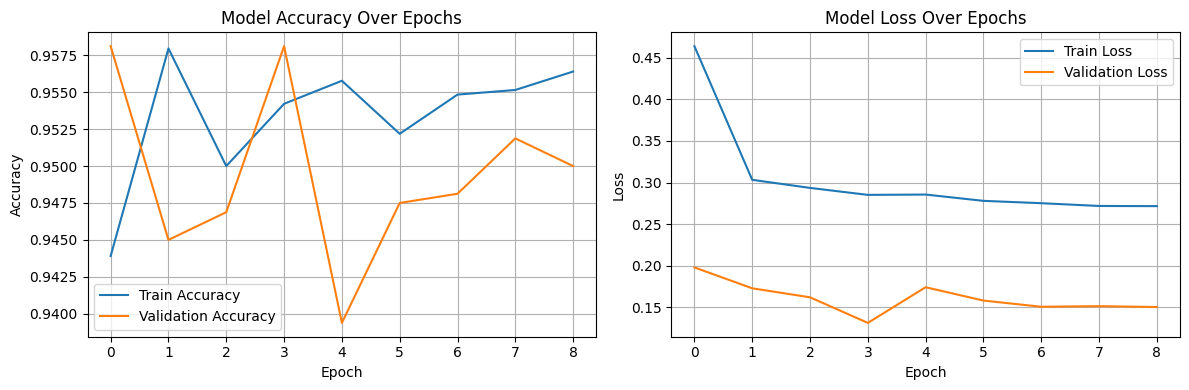

In [8]:
# 6️⃣ TRAINING HISTORY VISUALIZATION
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Confusion Matrix

<Figure size 600x500 with 0 Axes>

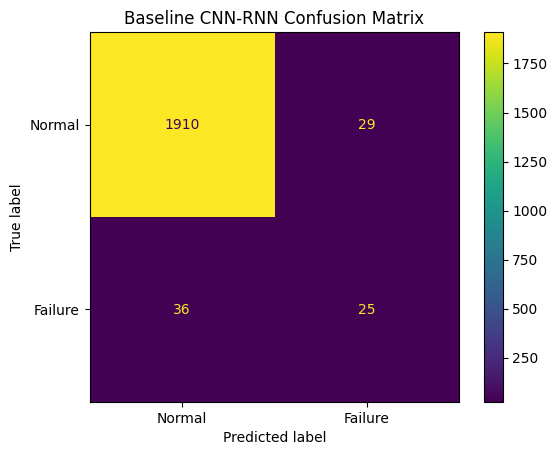

True Negatives: 1910
False Positives: 29
False Negatives: 36
True Positives: 25


In [9]:
# 7️⃣ CONFUSION MATRIX ANALYSIS
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_labels)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Failure']).plot()
plt.title("Baseline CNN-RNN Confusion Matrix")
plt.show()

# Print confusion matrix stats
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

# ROC Curve

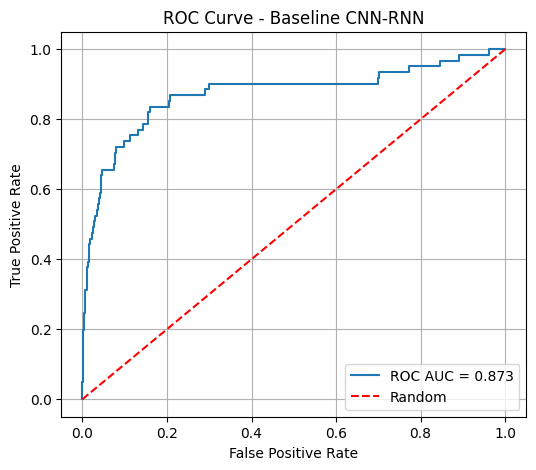

In [10]:
# 8️⃣ ROC CURVE ANALYSIS
plt.figure(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline CNN-RNN")
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall Analysis

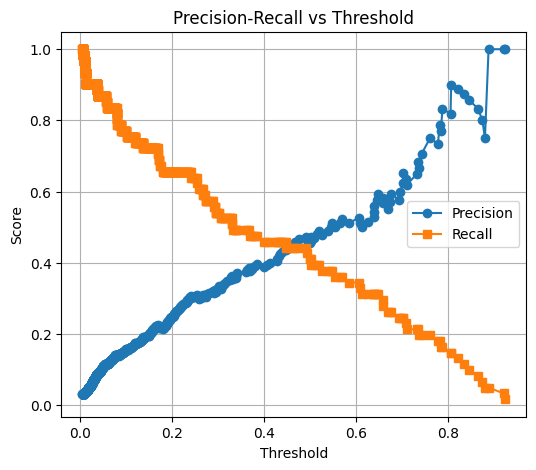

🎯 Optimal threshold: 0.491
🎯 Best F1 score: 0.458


In [11]:
# 9️⃣ PRECISION-RECALL ANALYSIS
plt.figure(figsize=(6, 5))
prec, rec, thresholds = precision_recall_curve(y_test, y_pred)

plt.plot(thresholds, prec[:-1], label='Precision', marker='o')
plt.plot(thresholds, rec[:-1], label='Recall', marker='s')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

# Find optimal threshold
f1_scores = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1])
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(f"🎯 Optimal threshold: {optimal_threshold:.3f}")
print(f"🎯 Best F1 score: {f1_scores[optimal_idx]:.3f}")

# Save Results

In [12]:
# 🔟 SAVE BASELINE MODEL AND RESULTS
print("💾 Saving baseline model and results...")

# Save model and scaler
model.save("../models/cnn_rnn_model_dataset.keras")
joblib.dump(scaler, "../models/scaler.pkl")

# Save metrics
with open("../results/baseline_metrics.csv", "w") as f:
    writer = csv.writer(f)
    writer.writerow(["Metric", "Value"])
    writer.writerow(["Loss", loss])
    writer.writerow(["Accuracy", accuracy])
    writer.writerow(["Recall", recall])
    writer.writerow(["ROC_AUC", roc_auc])
    writer.writerow(["Optimal_Threshold", optimal_threshold])

# Save predictions
results_df = pd.DataFrame({
    "True_Label": y_test.reset_index(drop=True),
    "Predicted_Probability": y_pred,
    "Predicted_Label": y_pred_labels
})
results_df.to_csv("../results/baseline_predictions.csv", index=False)

print("✅ Baseline exploration completed!")
print("📈 Next: Run 02_recall_boosting.ipynb for performance improvements")

💾 Saving baseline model and results...
✅ Baseline exploration completed!
📈 Next: Run 02_recall_boosting.ipynb for performance improvements
